# RPC Dataset Analysis & Preprocessing
## Part 1: Dataset Preparation for YOLO Training

**Goal**: Convert RPC dataset from COCO format to YOLO format with supercategory mapping

**Key Steps**:
1. Load and analyze dataset structure
2. Map 200 classes → 17 supercategories  
3. Convert COCO annotations to YOLO format
4. Create proper directory structure
5. Generate data.yaml for YOLO training

## 1. Environment Setup

In [1]:
# Install required packages
!pip install -q ultralytics opencv-python-headless pillow tqdm pandas matplotlib seaborn

import json
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict, Counter
import cv2
from PIL import Image

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Environment setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.6 MB/s eta 0:00:00
✓ Environment setup complete


## 2. Dataset Paths Configuration

In [2]:
# Input paths (Kaggle dataset)
DATASET_ROOT = Path('/kaggle/input/retail-product-checkout-dataset')

# Annotation files
TRAIN_JSON = DATASET_ROOT / 'instances_train2019.json'
VAL_JSON = DATASET_ROOT / 'instances_val2019.json'
TEST_JSON = DATASET_ROOT / 'instances_test2019.json'

# Image directories
TRAIN_IMAGES = DATASET_ROOT / 'train2019'
VAL_IMAGES = DATASET_ROOT / 'val2019'
TEST_IMAGES = DATASET_ROOT / 'test2019'

# Output paths (working directory)
OUTPUT_ROOT = Path('/kaggle/working/rpc_yolo')
OUTPUT_ROOT.mkdir(exist_ok=True, parents=True)

# Verify all files exist
print("Checking dataset files...")
for path in [TRAIN_JSON, VAL_JSON, TEST_JSON, TRAIN_IMAGES, VAL_IMAGES, TEST_IMAGES]:
    if path.exists():
        print(f"✓ {path.name}")
    else:
        print(f"✗ {path.name} NOT FOUND")

print(f"\nOutput directory: {OUTPUT_ROOT}")

Checking dataset files...
✓ instances_train2019.json
✓ instances_val2019.json
✓ instances_test2019.json
✓ train2019
✓ val2019
✓ test2019

Output directory: /kaggle/working/rpc_yolo


## 3. Load and Analyze Dataset

In [3]:
def load_coco_json(json_path):
    """Load COCO format annotation file"""
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

def analyze_dataset_split(data, split_name):
    """Analyze a dataset split"""
    print(f"\n{'='*80}")
    print(f"ANALYZING {split_name.upper()} SET")
    print(f"{'='*80}")
    
    n_images = len(data['images'])
    n_annotations = len(data['annotations'])
    n_categories = len(data['categories'])
    
    print(f"Total Images: {n_images:,}")
    print(f"Total Annotations: {n_annotations:,}")
    print(f"Total Categories: {n_categories}")
    print(f"Avg annotations per image: {n_annotations/n_images:.2f}")
    
    # Objects per image distribution
    img_id_to_count = Counter()
    for ann in data['annotations']:
        img_id_to_count[ann['image_id']] += 1
    
    counts = list(img_id_to_count.values())
    print(f"\nOBJECTS PER IMAGE:")
    print(f"  Average: {np.mean(counts):.2f}")
    print(f"  Median: {np.median(counts):.0f}")
    print(f"  Min: {min(counts)}")
    print(f"  Max: {max(counts)}")
    
    # Distribution
    count_dist = Counter(counts)
    print(f"\nDistribution:")
    for obj_count in sorted(count_dist.keys()):
        n_imgs = count_dist[obj_count]
        pct = 100 * n_imgs / n_images
        print(f"  {obj_count:2d} objects: {n_imgs:5d} images ({pct:5.1f}%)")
    
    return {
        'n_images': n_images,
        'n_annotations': n_annotations,
        'n_categories': n_categories,
        'obj_per_img': counts
    }

# Load all splits
print("Loading dataset splits...")
train_data = load_coco_json(TRAIN_JSON)
val_data = load_coco_json(VAL_JSON)
test_data = load_coco_json(TEST_JSON)

# Analyze each split
train_stats = analyze_dataset_split(train_data, 'train')
val_stats = analyze_dataset_split(val_data, 'validation')
test_stats = analyze_dataset_split(test_data, 'test')

Loading dataset splits...

ANALYZING TRAIN SET
Total Images: 53,739
Total Annotations: 53,739
Total Categories: 200
Avg annotations per image: 1.00

OBJECTS PER IMAGE:
  Average: 1.00
  Median: 1
  Min: 1
  Max: 1

Distribution:
   1 objects: 53739 images (100.0%)

ANALYZING VALIDATION SET
Total Images: 6,000
Total Annotations: 73,602
Total Categories: 200
Avg annotations per image: 12.27

OBJECTS PER IMAGE:
  Average: 12.27
  Median: 12
  Min: 4
  Max: 20

Distribution:
   4 objects:   102 images (  1.7%)
   5 objects:   294 images (  4.9%)
   6 objects:   321 images (  5.3%)
   7 objects:   407 images (  6.8%)
   8 objects:   385 images (  6.4%)
   9 objects:   362 images (  6.0%)
  10 objects:   411 images (  6.8%)
  11 objects:   395 images (  6.6%)
  12 objects:   360 images (  6.0%)
  13 objects:   412 images (  6.9%)
  14 objects:   374 images (  6.2%)
  15 objects:   537 images (  8.9%)
  16 objects:   377 images (  6.3%)
  17 objects:   325 images (  5.4%)
  18 objects:   403 

## 4. Build Supercategory Mapping

In [4]:
def build_supercategory_mapping(categories):
    """
    Build mapping from 200 fine-grained categories to 17 supercategories
    Returns: category_id -> supercategory_id mapping and class names
    """
    # Extract unique supercategories
    supercategories = sorted(set(cat['supercategory'] for cat in categories))
    
    # Create supercategory -> id mapping (0-indexed for YOLO)
    supercat_to_id = {sc: idx for idx, sc in enumerate(supercategories)}
    
    # Create category_id -> supercategory_id mapping
    cat_id_to_supercat_id = {}
    for cat in categories:
        cat_id = cat['id']
        supercat = cat['supercategory']
        cat_id_to_supercat_id[cat_id] = supercat_to_id[supercat]
    
    return cat_id_to_supercat_id, supercategories, supercat_to_id

# Build mapping from training data
cat_to_supercat, class_names, supercat_to_id = build_supercategory_mapping(
    train_data['categories']
)

print(f"\n{'='*80}")
print("SUPERCATEGORY MAPPING")
print(f"{'='*80}")
print(f"\nTotal supercategories: {len(class_names)}")
print(f"\nClass mapping (YOLO format):")
for idx, name in enumerate(class_names):
    print(f"  {idx:2d}: {name}")

# Analyze supercategory distribution
def analyze_supercategory_distribution(data, cat_to_supercat, class_names):
    """Analyze distribution of supercategories in annotations"""
    supercat_counts = Counter()
    
    for ann in data['annotations']:
        supercat_id = cat_to_supercat[ann['category_id']]
        supercat_counts[supercat_id] += 1
    
    total = sum(supercat_counts.values())
    
    print(f"\nSupercategory distribution:")
    for supercat_id in sorted(supercat_counts.keys()):
        count = supercat_counts[supercat_id]
        pct = 100 * count / total
        print(f"  {class_names[supercat_id]:20s}: {count:6d} ({pct:5.1f}%)")
    
    return supercat_counts

print(f"\n{'='*80}")
print("TRAIN SET DISTRIBUTION")
print(f"{'='*80}")
train_supercat_dist = analyze_supercategory_distribution(train_data, cat_to_supercat, class_names)


SUPERCATEGORY MAPPING

Total supercategories: 17

Class mapping (YOLO format):
   0: alcohol
   1: candy
   2: canned_food
   3: chocolate
   4: dessert
   5: dried_food
   6: dried_fruit
   7: drink
   8: gum
   9: instant_drink
  10: instant_noodles
  11: milk
  12: personal_hygiene
  13: puffed_food
  14: seasoner
  15: stationery
  16: tissue

TRAIN SET DISTRIBUTION

Supercategory distribution:
  alcohol             :   1759 (  3.3%)
  candy               :   3040 (  5.7%)
  canned_food         :   2238 (  4.2%)
  chocolate           :   4320 (  8.0%)
  dessert             :   5278 (  9.8%)
  dried_food          :   2875 (  5.3%)
  dried_fruit         :   2873 (  5.3%)
  drink               :   2400 (  4.5%)
  gum                 :   2240 (  4.2%)
  instant_drink       :   2878 (  5.4%)
  instant_noodles     :   3039 (  5.7%)
  milk                :   1760 (  3.3%)
  personal_hygiene    :   2720 (  5.1%)
  puffed_food         :   3840 (  7.1%)
  seasoner            :   3200 (  6.0

## 5. Visualize Distribution Shift

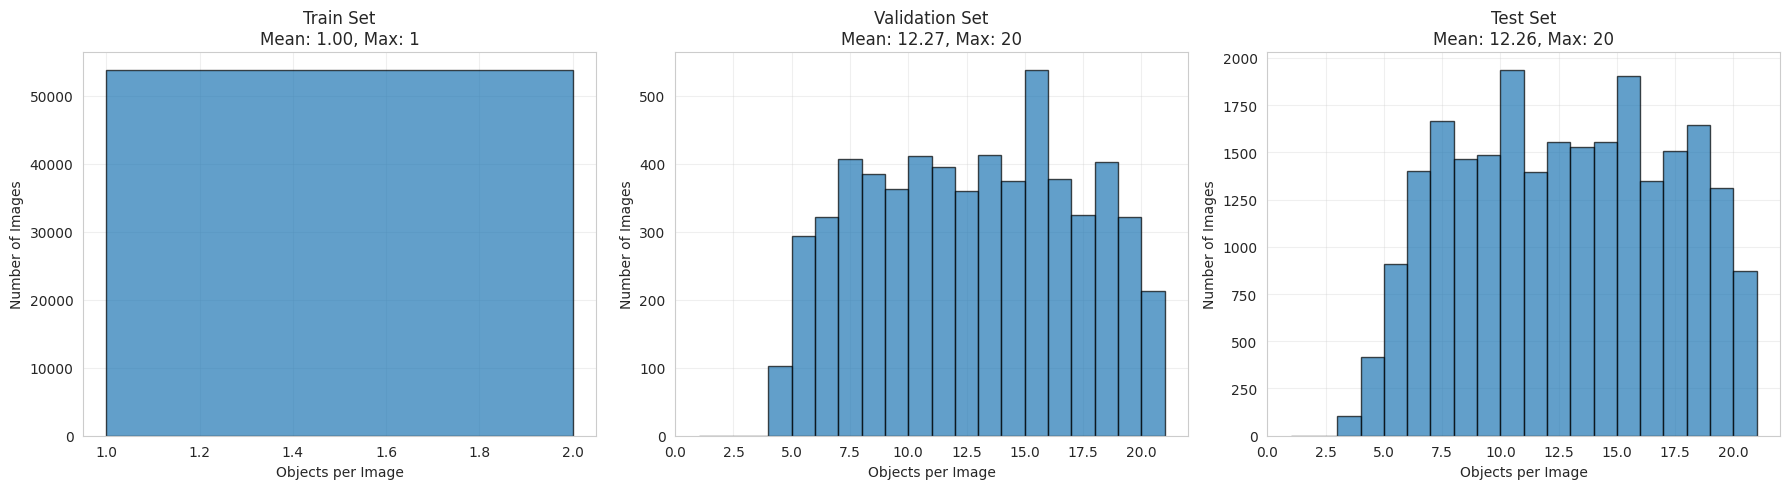


⚠️  CRITICAL DISTRIBUTION SHIFT DETECTED:
   Train: 1.00 objects/image
   Val:   12.27 objects/image
   Test:  12.26 objects/image

   This is a 12.3x increase!


In [5]:
# Create visualization of objects per image across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (stats, name) in zip(axes, [
    (train_stats, 'Train'),
    (val_stats, 'Validation'),
    (test_stats, 'Test')
]):
    counts = stats['obj_per_img']
    ax.hist(counts, bins=range(1, max(counts)+2), edgecolor='black', alpha=0.7)
    ax.set_xlabel('Objects per Image')
    ax.set_ylabel('Number of Images')
    ax.set_title(f'{name} Set\nMean: {np.mean(counts):.2f}, Max: {max(counts)}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_ROOT / 'distribution_shift.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n⚠️  CRITICAL DISTRIBUTION SHIFT DETECTED:")
print(f"   Train: {np.mean(train_stats['obj_per_img']):.2f} objects/image")
print(f"   Val:   {np.mean(val_stats['obj_per_img']):.2f} objects/image")
print(f"   Test:  {np.mean(test_stats['obj_per_img']):.2f} objects/image")
print(f"\n   This is a {np.mean(test_stats['obj_per_img'])/np.mean(train_stats['obj_per_img']):.1f}x increase!")

## 6. COCO to YOLO Format Conversion

In [6]:
def coco_to_yolo_bbox(bbox, img_width, img_height):
    """
    Convert COCO bbox [x, y, width, height] to YOLO format [x_center, y_center, width, height]
    All values normalized to [0, 1]
    """
    x, y, w, h = bbox
    
    # Convert to center coordinates
    x_center = x + w / 2
    y_center = y + h / 2
    
    # Normalize
    x_center /= img_width
    y_center /= img_height
    w /= img_width
    h /= img_height
    
    return x_center, y_center, w, h

def convert_split_to_yolo(data, images_dir, output_dir, split_name, cat_to_supercat):
    """
    Convert COCO format dataset to YOLO format
    
    Args:
        data: COCO format data dict
        images_dir: Path to images
        output_dir: Path to output YOLO dataset
        split_name: 'train', 'val', or 'test'
        cat_to_supercat: category_id -> supercategory_id mapping
    """
    # Create directories
    images_out = output_dir / 'images' / split_name
    labels_out = output_dir / 'labels' / split_name
    images_out.mkdir(parents=True, exist_ok=True)
    labels_out.mkdir(parents=True, exist_ok=True)
    
    # Build image_id -> image info mapping
    img_id_to_info = {img['id']: img for img in data['images']}
    
    # Group annotations by image
    img_id_to_anns = defaultdict(list)
    for ann in data['annotations']:
        img_id_to_anns[ann['image_id']].append(ann)
    
    print(f"\nConverting {split_name} split to YOLO format...")
    
    converted = 0
    skipped = 0
    
    for img_id, img_info in tqdm(img_id_to_info.items(), desc=f"Processing {split_name}"):
        filename = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']
        
        src_img_path = images_dir / filename
        
        # Skip if image doesn't exist
        if not src_img_path.exists():
            skipped += 1
            continue
        
        # Copy image (create symlink to save space on Kaggle)
        dst_img_path = images_out / filename
        if not dst_img_path.exists():
            os.symlink(src_img_path, dst_img_path)
        
        # Convert annotations
        anns = img_id_to_anns.get(img_id, [])
        
        # Create YOLO label file
        label_path = labels_out / (Path(filename).stem + '.txt')
        
        with open(label_path, 'w') as f:
            for ann in anns:
                # Get supercategory ID
                class_id = cat_to_supercat[ann['category_id']]
                
                # Convert bbox
                x_center, y_center, w, h = coco_to_yolo_bbox(
                    ann['bbox'], img_width, img_height
                )
                
                # Write YOLO format: class x_center y_center width height
                f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")
        
        converted += 1
    
    print(f"✓ Converted: {converted} images")
    if skipped > 0:
        print(f"⚠ Skipped: {skipped} images (not found)")
    
    return converted, skipped

# Convert all splits
yolo_dataset_dir = OUTPUT_ROOT / 'yolo_dataset'

print(f"\n{'='*80}")
print("CONVERTING TO YOLO FORMAT")
print(f"{'='*80}")

train_conv = convert_split_to_yolo(train_data, TRAIN_IMAGES, yolo_dataset_dir, 'train', cat_to_supercat)
val_conv = convert_split_to_yolo(val_data, VAL_IMAGES, yolo_dataset_dir, 'val', cat_to_supercat)
test_conv = convert_split_to_yolo(test_data, TEST_IMAGES, yolo_dataset_dir, 'test', cat_to_supercat)

print(f"\n✓ YOLO dataset created at: {yolo_dataset_dir}")


CONVERTING TO YOLO FORMAT

Converting train split to YOLO format...


Processing train:   0%|          | 0/53739 [00:00<?, ?it/s]

✓ Converted: 53739 images

Converting val split to YOLO format...


Processing val:   0%|          | 0/6000 [00:00<?, ?it/s]

✓ Converted: 6000 images

Converting test split to YOLO format...


Processing test:   0%|          | 0/24000 [00:00<?, ?it/s]

✓ Converted: 24000 images

✓ YOLO dataset created at: /kaggle/working/rpc_yolo/yolo_dataset


## 7. Create data.yaml for YOLO Training

In [7]:
# Create data.yaml file
data_yaml_content = f"""# RPC Dataset - Supercategory Detection
# Generated automatically from COCO format

path: {yolo_dataset_dir.absolute()}  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val      # val images (relative to 'path')
test: images/test    # test images (relative to 'path')

# Number of classes
nc: {len(class_names)}

# Class names (supercategories)
names:
"""

for idx, name in enumerate(class_names):
    data_yaml_content += f"  {idx}: {name}\n"

data_yaml_path = yolo_dataset_dir / 'data.yaml'
with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content)

print(f"\n{'='*80}")
print("data.yaml CREATED")
print(f"{'='*80}")
print(data_yaml_content)
print(f"\n✓ Saved to: {data_yaml_path}")


data.yaml CREATED
# RPC Dataset - Supercategory Detection
# Generated automatically from COCO format

path: /kaggle/working/rpc_yolo/yolo_dataset  # dataset root dir
train: images/train  # train images (relative to 'path')
val: images/val      # val images (relative to 'path')
test: images/test    # test images (relative to 'path')

# Number of classes
nc: 17

# Class names (supercategories)
names:
  0: alcohol
  1: candy
  2: canned_food
  3: chocolate
  4: dessert
  5: dried_food
  6: dried_fruit
  7: drink
  8: gum
  9: instant_drink
  10: instant_noodles
  11: milk
  12: personal_hygiene
  13: puffed_food
  14: seasoner
  15: stationery
  16: tissue


✓ Saved to: /kaggle/working/rpc_yolo/yolo_dataset/data.yaml


## 8. Verify Dataset Structure

In [8]:
def verify_yolo_dataset(dataset_dir):
    """Verify YOLO dataset structure and contents"""
    print(f"\n{'='*80}")
    print("VERIFYING YOLO DATASET")
    print(f"{'='*80}")
    
    for split in ['train', 'val', 'test']:
        img_dir = dataset_dir / 'images' / split
        lbl_dir = dataset_dir / 'labels' / split
        
        n_images = len(list(img_dir.glob('*.jpg')))
        n_labels = len(list(lbl_dir.glob('*.txt')))
        
        print(f"\n{split.upper()} split:")
        print(f"  Images: {n_images:,}")
        print(f"  Labels: {n_labels:,}")
        
        if n_images != n_labels:
            print(f"  ⚠️  WARNING: Image count doesn't match label count!")
        else:
            print(f"  ✓ Counts match")
        
        # Sample a few labels to verify format
        sample_labels = list(lbl_dir.glob('*.txt'))[:3]
        if sample_labels:
            print(f"\n  Sample label file: {sample_labels[0].name}")
            with open(sample_labels[0], 'r') as f:
                lines = f.readlines()[:3]
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, x, y, w, h = parts
                        print(f"    Class {cls}: [{float(x):.4f}, {float(y):.4f}, {float(w):.4f}, {float(h):.4f}]")

verify_yolo_dataset(yolo_dataset_dir)


VERIFYING YOLO DATASET

TRAIN split:
  Images: 53,739
  Labels: 53,739
  ✓ Counts match

  Sample label file: 6922868282265~B_camera1-27.txt
    Class 16: [0.4294, 0.3473, 0.0872, 0.1157]

VAL split:
  Images: 6,000
  Labels: 6,000
  ✓ Counts match

  Sample label file: 20180904-11-25-43-2796.txt
    Class 1: [0.4635, 0.5183, 0.0541, 0.1519]
    Class 1: [0.6910, 0.5055, 0.1351, 0.1147]
    Class 1: [0.5467, 0.4945, 0.0614, 0.1512]

TEST split:
  Images: 24,000
  Labels: 24,000
  ✓ Counts match

  Sample label file: 20180905-11-14-47-212.txt
    Class 6: [0.6636, 0.7710, 0.3088, 0.2408]
    Class 4: [0.7561, 0.5785, 0.2463, 0.1823]
    Class 8: [0.7520, 0.4595, 0.1320, 0.1184]


## 9. Visualize Sample Converted Data

Visualizing converted YOLO data...



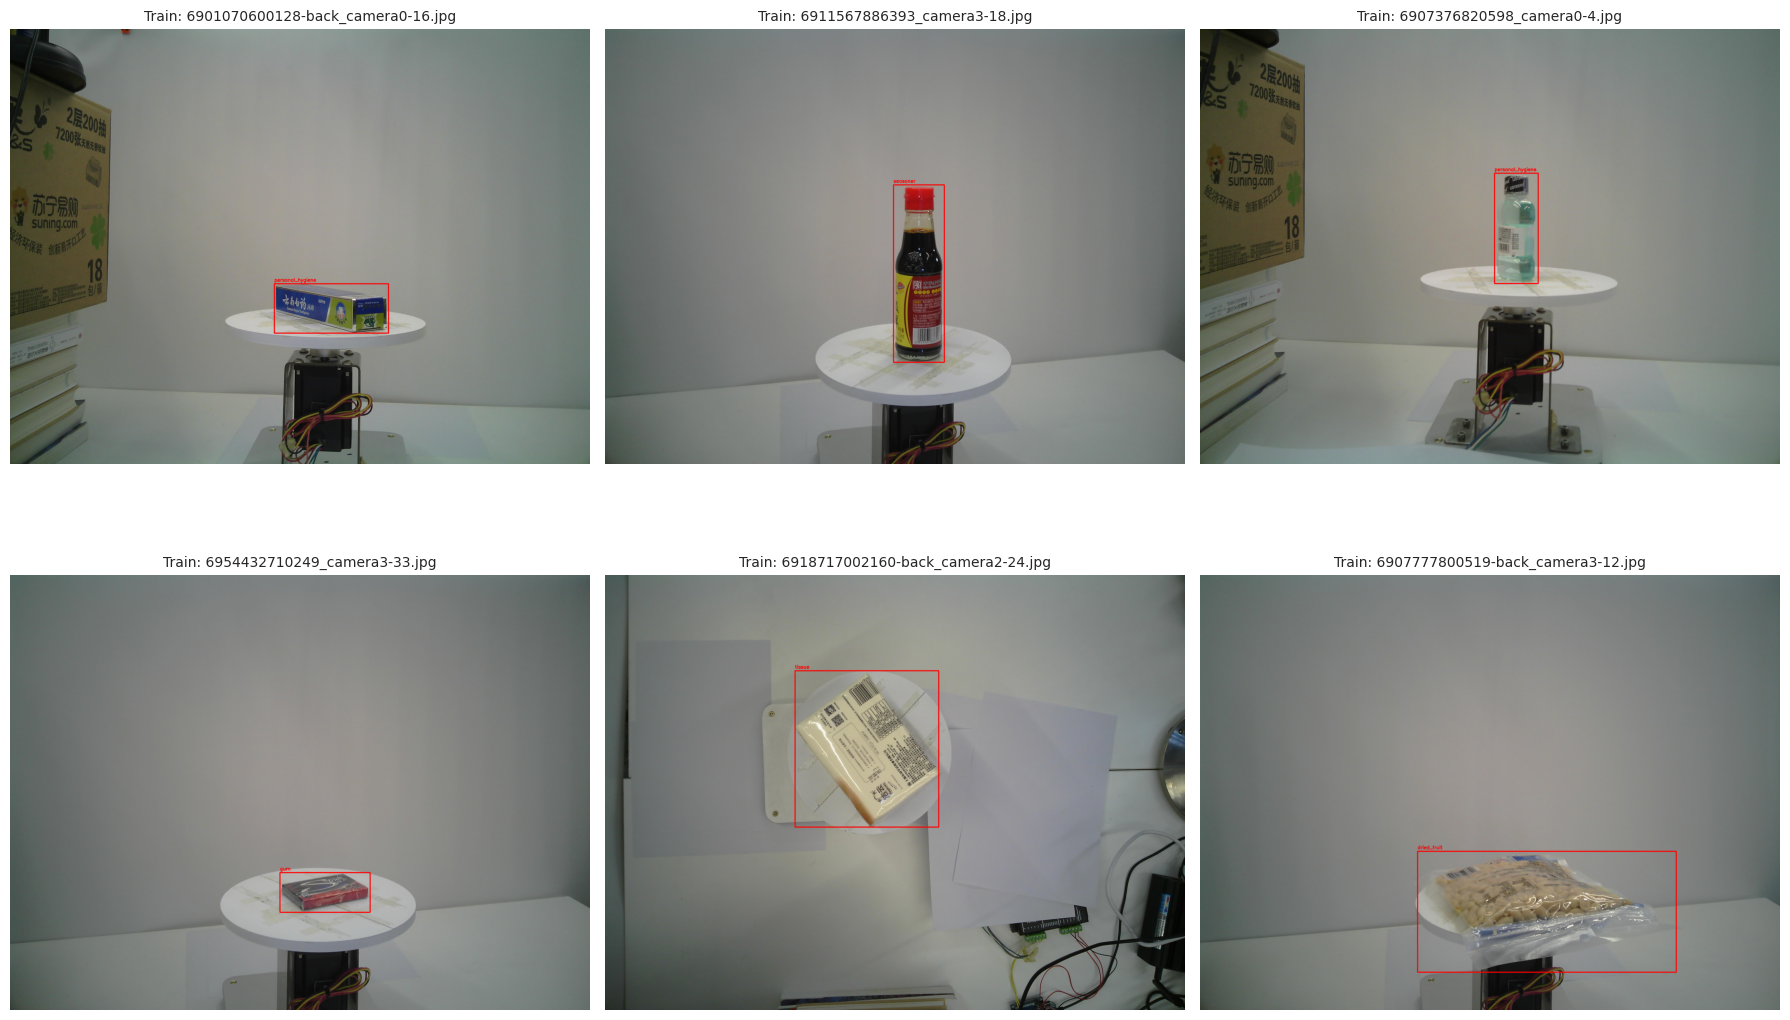

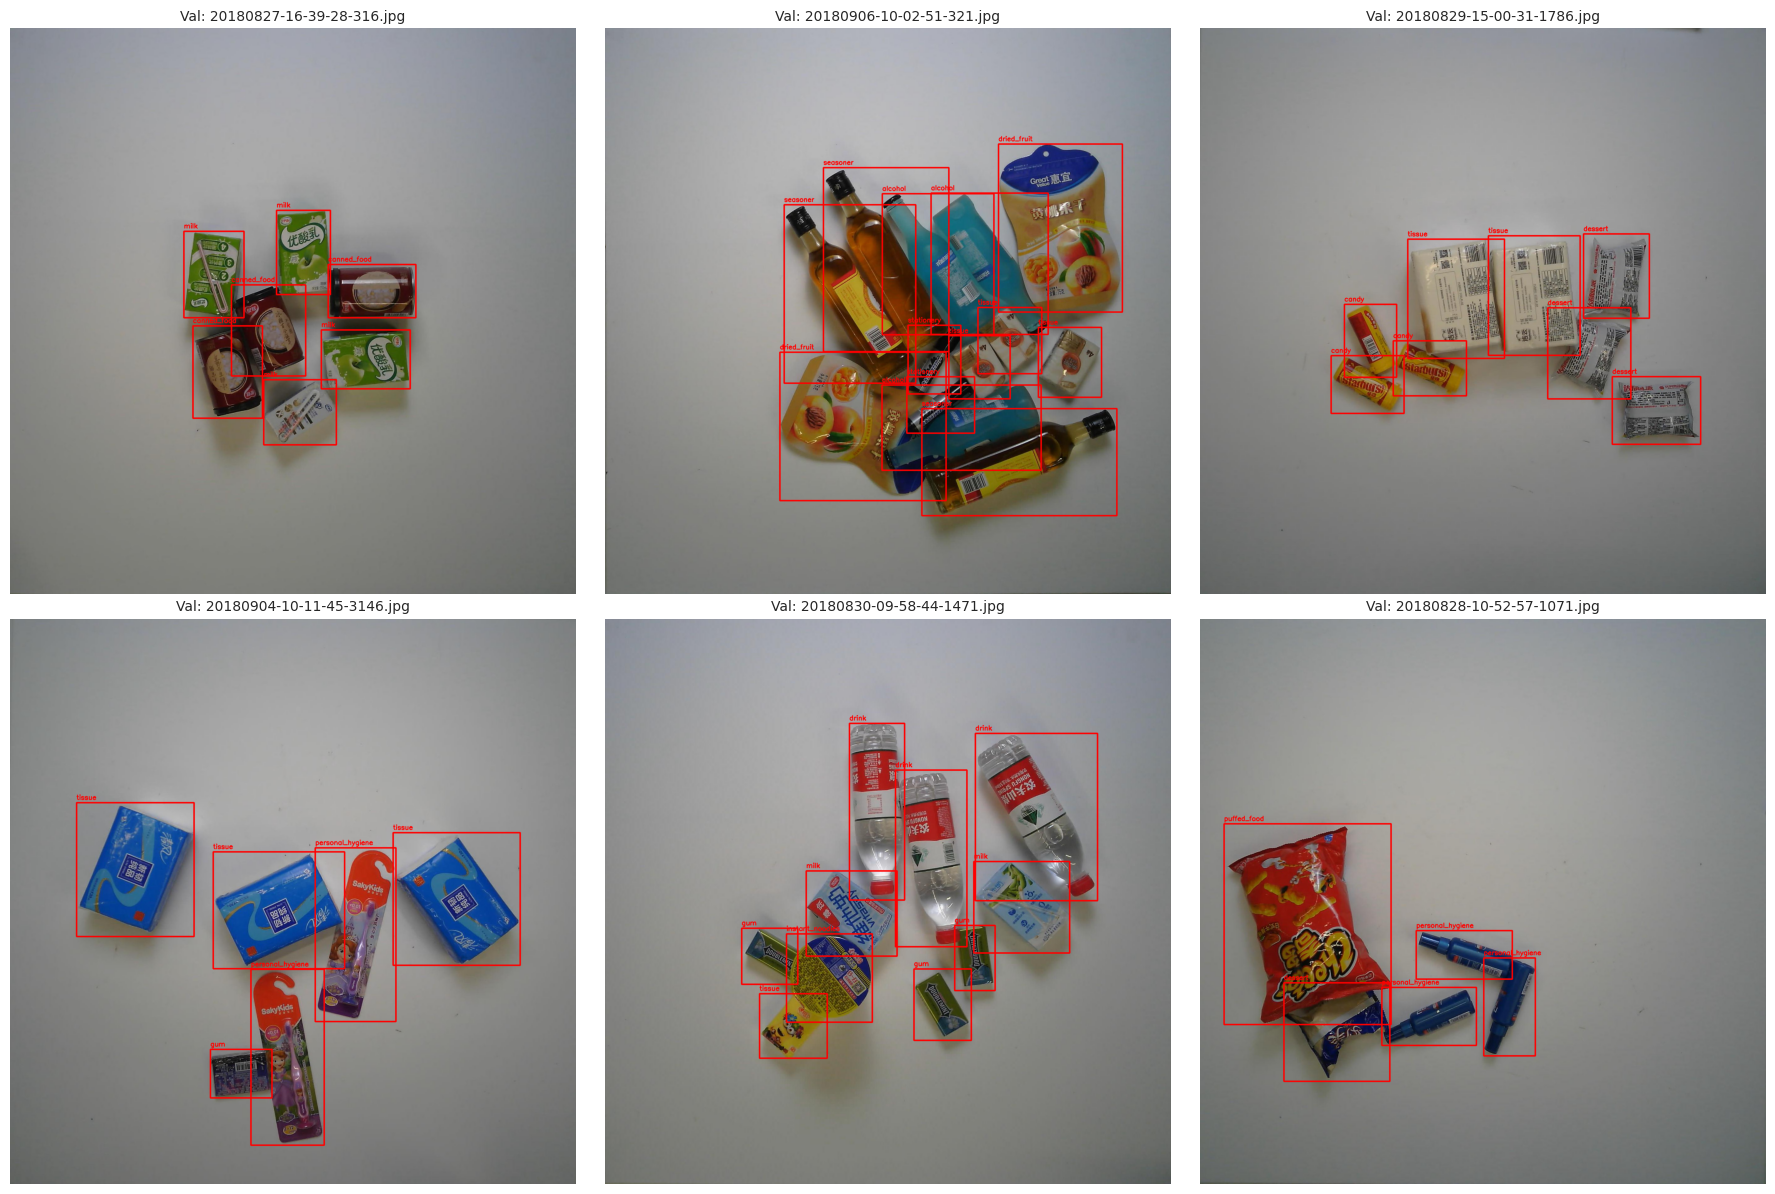

In [9]:
def visualize_yolo_samples(dataset_dir, split='train', num_samples=6):
    """Visualize samples from converted YOLO dataset"""
    img_dir = dataset_dir / 'images' / split
    lbl_dir = dataset_dir / 'labels' / split
    
    # Get sample images
    img_files = list(img_dir.glob('*.jpg'))[:num_samples]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, img_file in enumerate(img_files):
        if idx >= num_samples:
            break
        
        # Read image
        img = cv2.imread(str(img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Read labels
        lbl_file = lbl_dir / (img_file.stem + '.txt')
        
        if lbl_file.exists():
            with open(lbl_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls_id, x_c, y_c, box_w, box_h = map(float, parts)
                        cls_id = int(cls_id)
                        
                        # Convert normalized coords to pixel coords
                        x_c *= w
                        y_c *= h
                        box_w *= w
                        box_h *= h
                        
                        # Convert to corner coords
                        x1 = int(x_c - box_w/2)
                        y1 = int(y_c - box_h/2)
                        x2 = int(x_c + box_w/2)
                        y2 = int(y_c + box_h/2)
                        
                        # Draw box
                        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
                        
                        # Add label
                        label_text = class_names[cls_id]
                        cv2.putText(img, label_text, (x1, y1-10),
                                  cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f"{split.capitalize()}: {img_file.name}", fontsize=10)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_ROOT / f'yolo_samples_{split}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize samples from each split
print("Visualizing converted YOLO data...\n")
visualize_yolo_samples(yolo_dataset_dir, 'train', 6)
visualize_yolo_samples(yolo_dataset_dir, 'val', 6)

## 10. Save Processing Summary

In [10]:
# Create comprehensive summary
summary = {
    'dataset': 'RPC (Retail Product Checkout)',
    'original_classes': 200,
    'supercategories': len(class_names),
    'class_names': class_names,
    'splits': {
        'train': {
            'images': train_stats['n_images'],
            'annotations': train_stats['n_annotations'],
            'avg_obj_per_img': np.mean(train_stats['obj_per_img'])
        },
        'val': {
            'images': val_stats['n_images'],
            'annotations': val_stats['n_annotations'],
            'avg_obj_per_img': np.mean(val_stats['obj_per_img'])
        },
        'test': {
            'images': test_stats['n_images'],
            'annotations': test_stats['n_annotations'],
            'avg_obj_per_img': np.mean(test_stats['obj_per_img'])
        }
    },
    'distribution_shift': {
        'train_avg_objects': np.mean(train_stats['obj_per_img']),
        'test_avg_objects': np.mean(test_stats['obj_per_img']),
        'shift_ratio': np.mean(test_stats['obj_per_img']) / np.mean(train_stats['obj_per_img'])
    },
    'yolo_dataset_path': str(yolo_dataset_dir.absolute()),
    'data_yaml_path': str(data_yaml_path.absolute())
}

# Save summary
summary_path = OUTPUT_ROOT / 'preprocessing_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n{'='*80}")
print("PREPROCESSING COMPLETE")
print(f"{'='*80}")
print(f"\n✓ YOLO dataset: {yolo_dataset_dir}")
print(f"✓ data.yaml: {data_yaml_path}")
print(f"✓ Summary: {summary_path}")
print(f"\n{'='*80}")
print("KEY FINDINGS")
print(f"{'='*80}")
print(f"Classes: {summary['original_classes']} → {summary['supercategories']} (supercategories)")
print(f"Distribution shift: {summary['distribution_shift']['shift_ratio']:.1f}x")
print(f"  - Train: {summary['distribution_shift']['train_avg_objects']:.2f} objects/image")
print(f"  - Test: {summary['distribution_shift']['test_avg_objects']:.2f} objects/image")
print(f"\n⚠️  CRITICAL: Synthetic multi-object training is REQUIRED!")
print(f"   Proceed to Notebook 2 for synthetic data generation.")


PREPROCESSING COMPLETE

✓ YOLO dataset: /kaggle/working/rpc_yolo/yolo_dataset
✓ data.yaml: /kaggle/working/rpc_yolo/yolo_dataset/data.yaml
✓ Summary: /kaggle/working/rpc_yolo/preprocessing_summary.json

KEY FINDINGS
Classes: 200 → 17 (supercategories)
Distribution shift: 12.3x
  - Train: 1.00 objects/image
  - Test: 12.26 objects/image

⚠️  CRITICAL: Synthetic multi-object training is REQUIRED!
   Proceed to Notebook 2 for synthetic data generation.
